In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# STREAMLIT

FINANCIAL PROFILE

1. Customer Financial Strength and Subscription Conversion

# Previous Campaign Effectiveness

Previous Campaign Outcome vs Conversion Rate

Conversion rate by previous campaign result:
previous_campaign_result
No Previous Campaign Contact    0.091615
Previous Campaign Failure       0.126097
Outcome Unrecorded              0.166848
Previous Campaign Success       0.647253
Name: converted, dtype: float64


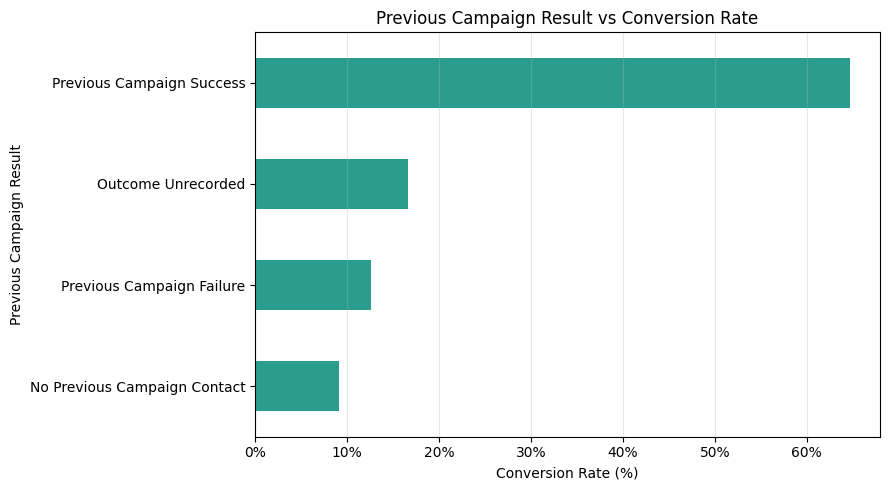

In [25]:
# Load dataset
df = pd.read_csv("../../data/raw/bank-full.csv", sep=";")

# Convert target to numeric
df["converted"] = df["y"].map({"yes": 1, "no": 0})

# Create executive-friendly labels
df["previous_campaign_result"] = df["poutcome"].replace({
    "success": "Previous Campaign Success",
    "failure": "Previous Campaign Failure",
    "unknown": "No Previous Campaign Contact",
    "other": "Outcome Unrecorded"
})

# Calculate conversion rate
conversion_by_outcome = (
    df.groupby("previous_campaign_result")["converted"]
    .mean()
    .sort_values()
)

print("Conversion rate by previous campaign result:")
print(conversion_by_outcome)

# Plot
fig, ax = plt.subplots(figsize=(9,5))

conversion_by_outcome.plot(
    kind="barh",
    ax=ax,
    color="#2a9d8f"
)

ax.set_title("Previous Campaign Result vs Conversion Rate")
ax.set_xlabel("Conversion Rate (%)")
ax.set_ylabel("Previous Campaign Result")
ax.grid(axis="x", alpha=0.3)

# Format x-axis as percentages
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))

plt.tight_layout()
plt.show()

Time Since Last Contact vs Conversion Rate

  last_contact_timing  n_customers  conversion_rate
0           0–30 Days          188         0.148936
1          31–90 Days          530         0.420755
2            90+ Days         7539         0.219392
3     Never Contacted        36954         0.091573


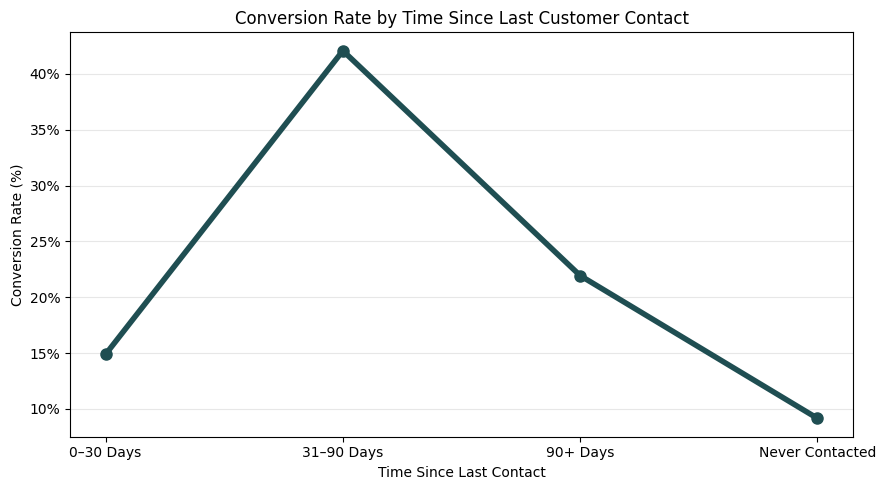

In [31]:
# Load dataset
df = pd.read_csv("../../data/raw/bank-full.csv", sep=";")

# Convert target to numeric
df["converted"] = df["y"].map({"yes": 1, "no": 0})

# Create contact timing groups
def contact_recency(days):
    if days == -1:
        return "Never Contacted"
    if days <= 30:
        return "0–30 Days"
    if days <= 90:
        return "31–90 Days"
    return "90+ Days"

df["last_contact_timing"] = df["pdays"].apply(contact_recency)

order = ["0–30 Days", "31–90 Days", "90+ Days", "Never Contacted"]

summary = (
    df.groupby("last_contact_timing")["converted"]
    .agg(n_customers="count", conversion_rate="mean")
    .reindex(order)
    .reset_index()
)

print(summary)

# Plot
fig, ax = plt.subplots(figsize=(9,5))

ax.plot(
    summary["last_contact_timing"],
    summary["conversion_rate"],
    marker="o",
    linewidth=4,
    markersize=8,
    color="#1F4E52"
)

ax.set_title("Conversion Rate by Time Since Last Customer Contact")
ax.set_xlabel("Time Since Last Contact")
ax.set_ylabel("Conversion Rate (%)")
ax.grid(axis="y", alpha=0.3)

# Format percentages
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

plt.tight_layout()
plt.show()

Existing vs New Customer Conversion Rate

Conversion rate by customer type:
customer_type
New Customer         0.091573
Existing Customer    0.230713
Name: converted, dtype: float64


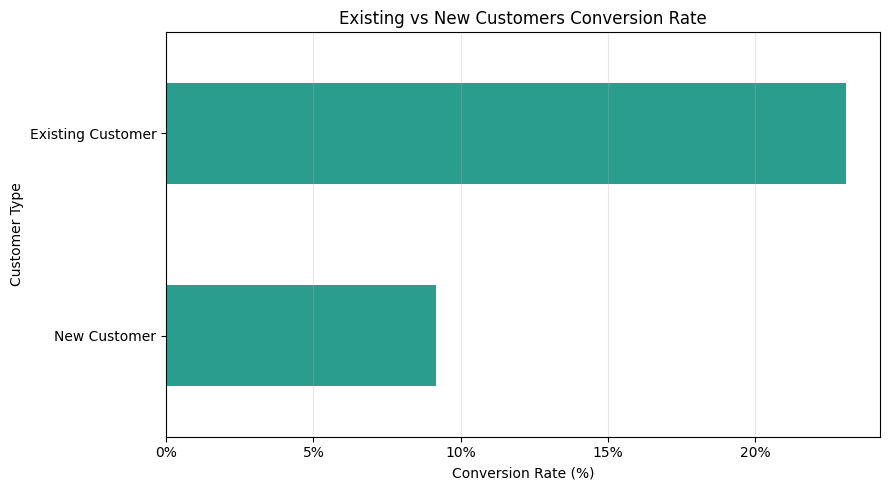

In [29]:
# Load dataset
df = pd.read_csv("../../data/raw/bank-full.csv", sep=";")

# Convert target to numeric
df["converted"] = df["y"].map({"yes": 1, "no": 0})

# Define customer type
df["customer_type"] = df["pdays"].apply(
    lambda x: "New Customer" if x == -1 else "Existing Customer"
)

# Calculate conversion rate
conversion_by_customer = (
    df.groupby("customer_type")["converted"]
    .mean()
    .sort_values()
)

print("Conversion rate by customer type:")
print(conversion_by_customer)

# Plot
fig, ax = plt.subplots(figsize=(9,5))

conversion_by_customer.plot(
    kind="barh",
    ax=ax,
    color="#2a9d8f"
)

ax.set_title("Existing vs New Customers Conversion Rate")
ax.set_xlabel("Conversion Rate (%)")
ax.set_ylabel("Customer Type")
ax.grid(axis="x", alpha=0.3)

# Format percentages
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))

plt.tight_layout()
plt.show()